Đang tải bộ dữ liệu CNN/DailyMail...
Số mẫu huấn luyện: 10000
Số mẫu kiểm tra: 500

######################################################################
# TIẾN HÀNH THỰC NGHIỆM VỚI 4 EPOCH
######################################################################

BẮT ĐẦU HUẤN LUYỆN: t5-small


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,2.055454,1.877211
2,1.979212,1.868861
3,1.975452,1.867638
4,2.002553,1.868286


...

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,2.256860,1.986960
2,1.921232,1.946220
3,1.671615,1.949092
4,1.510748,1.965197



Đang đánh giá facebook/bart-base trên 100 mẫu test...

KẾT QUẢ facebook/bart-base:
ROUGE-1 : 0.3970
ROUGE-2 : 0.1730
ROUGE-L : 0.2698
BLEU    : 0.1484

TỔNG KẾT SO SÁNH (4 EPOCH)
Mô hình         ROUGE-1    ROUGE-2    ROUGE-L    BLEU      
-------------------------------------------------------
T5-small        0.3763    0.1630    0.2671    0.1495
BART-base       0.3970    0.1730    0.2698    0.1484


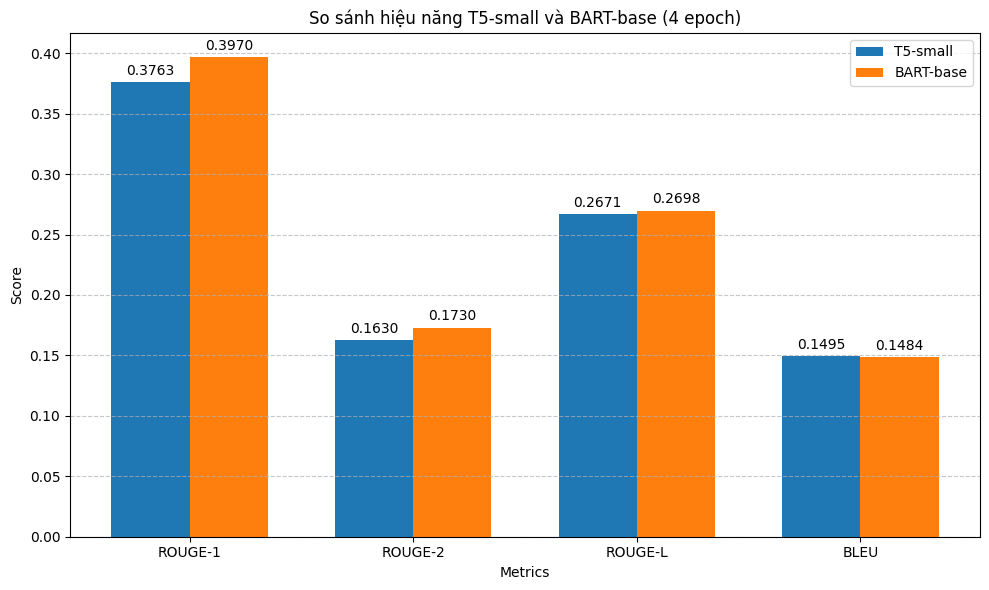


LƯU DATASET ĐÃ TOKENIZE CHO CẢ T5 VÀ BART
Đang tokenize và lưu cho T5...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Đã lưu T5 tokenized data vào: ./tokenized_data/t5/
Đang tokenize và lưu cho BART...


In [ ]:
# ============================================================================
# TIỂU LUẬN: ĐÁNH GIÁ BART VÀ T5 CHO TÓM TẮT VĂN BẢN (CNN/DailyMail)
# ============================================================================
# Thiết lập: 4 epoch cho mỗi mô hình, có biểu đồ so sánh
# Lưu tokenized dataset cho cả T5 và BART
# ============================================================================

# ------------------------- 1. CÀI ĐẶT THƯ VIỆN -------------------------
!pip install transformers datasets evaluate rouge_score sacrebleu -q

# ------------------------- 2. IMPORT THƯ VIỆN -------------------------
import torch
import os
import numpy as np
import matplotlib.pyplot as plt          # <-- Thêm cho biểu đồ
from datasets import load_dataset
from transformers import (
    T5Tokenizer, T5ForConditionalGeneration,
    BartTokenizer, BartForConditionalGeneration,
    Trainer, TrainingArguments, DataCollatorForSeq2Seq
)
import evaluate

# ------------------------- 3. LOAD DATASET -------------------------
print("Đang tải bộ dữ liệu CNN/DailyMail...")
dataset = load_dataset("cnn_dailymail", "3.0.0")

# Lấy tập con để chạy nhanh
train_data = dataset["train"].shuffle(seed=42).select(range(10000))
test_data = dataset["test"].shuffle(seed=42).select(range(500))

print(f"Số mẫu huấn luyện: {len(train_data)}")
print(f"Số mẫu kiểm tra: {len(test_data)}")

# ------------------------- 4. HÀM TIỀN XỬ LÝ -------------------------
def preprocess_function(examples, tokenizer, prefix=""):
    inputs = [prefix + doc for doc in examples["article"]]
    model_inputs = tokenizer(inputs, max_length=512, truncation=True)

    labels = tokenizer(examples["highlights"], max_length=128, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# ------------------------- 5. HÀM HUẤN LUYỆN & ĐÁNH GIÁ -------------------------
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

def train_and_evaluate(model_name, model_class, tokenizer_class, prefix=""):
    print(f"\n{'='*60}")
    print(f"BẮT ĐẦU HUẤN LUYỆN: {model_name}")
    print(f"{'='*60}")

    # Khởi tạo tokenizer và model
    tokenizer = tokenizer_class.from_pretrained(model_name)
    model = model_class.from_pretrained(model_name)

    # Tokenize dữ liệu
    tokenized_train = train_data.map(
        lambda x: preprocess_function(x, tokenizer, prefix), batched=True
    )
    tokenized_test = test_data.map(
        lambda x: preprocess_function(x, tokenizer, prefix), batched=True
    )

    # Thiết lập tham số huấn luyện (4 EPOCH)
    training_args = TrainingArguments(
        output_dir=f"./results_{model_name.replace('/', '_')}",
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        num_train_epochs=4,                         # <-- 4 EPOCH
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="no",
        fp16=True,
        report_to="none"
    )

    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        data_collator=data_collator,
    )

    # Huấn luyện
    trainer.train()

    # ------------------------- ĐÁNH GIÁ -------------------------
    print(f"\nĐang đánh giá {model_name} trên 100 mẫu test...")
    predictions, references = [], []
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    for i in range(100):
        input_text = test_data[i]["article"]
        ref_text = test_data[i]["highlights"]

        inputs = tokenizer(
            prefix + input_text,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_length=128,
                num_beams=4,
                early_stopping=True
            )

        pred_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        predictions.append(pred_text)
        references.append([ref_text])

    # Tính ROUGE và BLEU
    rouge_score = rouge.compute(
        predictions=predictions,
        references=[r[0] for r in references]
    )
    bleu_score = bleu.compute(predictions=predictions, references=references)

    print(f"\nKẾT QUẢ {model_name}:")
    print(f"ROUGE-1 : {rouge_score['rouge1']:.4f}")
    print(f"ROUGE-2 : {rouge_score['rouge2']:.4f}")
    print(f"ROUGE-L : {rouge_score['rougeL']:.4f}")
    print(f"BLEU    : {bleu_score['bleu']:.4f}")

    return model, tokenizer, rouge_score, bleu_score

# ------------------------- 6. HUẤN LUYỆN CÁC MÔ HÌNH -------------------------
print("\n" + "#"*70)
print("# TIẾN HÀNH THỰC NGHIỆM VỚI 4 EPOCH")
print("#"*70)

# Huấn luyện T5-small
model_t5, tokenizer_t5, rouge_t5, bleu_t5 = train_and_evaluate(
    model_name="t5-small",
    model_class=T5ForConditionalGeneration,
    tokenizer_class=T5Tokenizer,
    prefix="summarize: "
)

# Huấn luyện BART-base
model_bart, tokenizer_bart, rouge_bart, bleu_bart = train_and_evaluate(
    model_name="facebook/bart-base",
    model_class=BartForConditionalGeneration,
    tokenizer_class=BartTokenizer,
    prefix=""
)

# ------------------------- 7. SO SÁNH KẾT QUẢ -------------------------
print("\n" + "="*60)
print("TỔNG KẾT SO SÁNH (4 EPOCH)")
print("="*60)
print(f"{'Mô hình':<15} {'ROUGE-1':<10} {'ROUGE-2':<10} {'ROUGE-L':<10} {'BLEU':<10}")
print("-"*55)
print(f"{'T5-small':<15} {rouge_t5['rouge1']:.4f}    {rouge_t5['rouge2']:.4f}    {rouge_t5['rougeL']:.4f}    {bleu_t5['bleu']:.4f}")
print(f"{'BART-base':<15} {rouge_bart['rouge1']:.4f}    {rouge_bart['rouge2']:.4f}    {rouge_bart['rougeL']:.4f}    {bleu_bart['bleu']:.4f}")
print("="*60)

# ------------------------- 8. BIỂU ĐỒ SO SÁNH -------------------------
# Dữ liệu cho biểu đồ
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU']
t5_scores = [
    rouge_t5['rouge1'],
    rouge_t5['rouge2'],
    rouge_t5['rougeL'],
    bleu_t5['bleu']
]
bart_scores = [
    rouge_bart['rouge1'],
    rouge_bart['rouge2'],
    rouge_bart['rougeL'],
    bleu_bart['bleu']
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, t5_scores, width, label='T5-small', color='#1f77b4')
bars2 = ax.bar(x + width/2, bart_scores, width, label='BART-base', color='#ff7f0e')

# Thêm giá trị lên đỉnh cột
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('So sánh hiệu năng T5-small và BART-base (4 epoch)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# ------------------------- 9. LƯU DỮ LIỆU ĐÃ TOKENIZE -------------------------
print("\n" + "="*60)
print("LƯU DATASET ĐÃ TOKENIZE CHO CẢ T5 VÀ BART")
print("="*60)

base_dir = "./tokenized_data"
os.makedirs(f"{base_dir}/t5/train", exist_ok=True)
os.makedirs(f"{base_dir}/t5/test", exist_ok=True)
os.makedirs(f"{base_dir}/bart/train", exist_ok=True)
os.makedirs(f"{base_dir}/bart/test", exist_ok=True)

# Tokenize và lưu cho T5
print("Đang tokenize và lưu cho T5...")
tokenized_train_t5 = train_data.map(
    lambda x: preprocess_function(x, tokenizer_t5, prefix="summarize: "), batched=True
)
tokenized_test_t5 = test_data.map(
    lambda x: preprocess_function(x, tokenizer_t5, prefix="summarize: "), batched=True
)
tokenized_train_t5.save_to_disk(f"{base_dir}/t5/train")
tokenized_test_t5.save_to_disk(f"{base_dir}/t5/test")
print(f"Đã lưu T5 tokenized data vào: {base_dir}/t5/")

# Tokenize và lưu cho BART
print("Đang tokenize và lưu cho BART...")
tokenized_train_bart = train_data.map(
    lambda x: preprocess_function(x, tokenizer_bart, prefix=""), batched=True
)
tokenized_test_bart = test_data.map(
    lambda x: preprocess_function(x, tokenizer_bart, prefix=""), batched=True
)
tokenized_train_bart.save_to_disk(f"{base_dir}/bart/train")
tokenized_test_bart.save_to_disk(f"{base_dir}/bart/test")
print(f"Đã lưu BART tokenized data vào: {base_dir}/bart/")

# ------------------------- 10. TEST SINH MẪU -------------------------
def generate_summary(model, tokenizer, text, prefix=""):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    inputs = tokenizer(prefix + text, return_tensors="pt", truncation=True, max_length=512).to(device)
    outputs = model.generate(**inputs, max_length=120, num_beams=4, early_stopping=True)
    return tokenizer.decode(
        outputs[0], skip_special_tokens=True)

print("\n" + "="*60)
print("MINH HỌA TÓM TẮT (5 MẪU ĐẦU TIÊN)")
print("="*60)

for i in range(5):
    article = test_data[i]["article"]
    reference = test_data[i]["highlights"]
    print(f"\n--- MẪU {i+1} ---")
    print("Reference:", reference)
    t5_sum = generate_summary(model_t5, tokenizer_t5, article, prefix="summarize: ")
    print("T5-small :", t5_sum)
    bart_sum = generate_summary(model_bart, tokenizer_bart, article)
    print("BART-base:", bart_sum)

print("\nHOÀN THÀNH!")